# Valio Aimo Purchase Order Analysis

## Challenge Overview
This notebook analyzes purchase order data to identify patterns that can help predict missing items and proactively contact customers.

**Key Objectives:**
1. Identify products with high shortage risk
2. Identify customers most affected by discrepancies
3. Discover temporal patterns (seasonality, day of week, etc.)
4. Analyze batch delivery patterns
5. Create risk scoring metrics for AI agent prioritization


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


## 1. Data Loading and Initial Exploration


In [ ]:
# Load the purchase order data
file_path = 'valio_aimo_purchases_junction_2025.csv'
df = pd.read_csv(file_path)

print(f"Purchase data shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head(10)


Data shape: (782783, 11)

Column names: ['order_number', 'po_row_number', 'customer_number', 'po_created_date', 'requested_delivery_date', 'product_code', 'plant', 'storage_location', 'ordered_qty', 'unit', 'received_qty']

First few rows:


,order_number,po_row_number,customer_number,po_created_date,requested_delivery_date,product_code,plant,storage_location,ordered_qty,unit,received_qty
0,2300000000,10,30386,2024-09-01,2024-09-03,407329,1001,2011.00,8.00,ST,8.00
1,2300000001,10,30386,2024-09-01,2024-09-03,408060,1001,2011.00,3.00,ST,3.00
2,2300000002,10,30386,2024-09-01,2024-09-03,407332,1001,2011.00,4.00,ST,4.00
3,2300000002,20,30386,2024-09-01,2024-09-03,407326,1001,2011.00,4.00,ST,4.00
4,2300000003,10,30386,2024-09-01,2024-09-04,407466,1001,2011.00,4.00,RAS,4.00
5,2300000003,20,30386,2024-09-01,2024-09-04,410602,1001,2011.00,5.00,ST,5.00
6,2300000004,10,30386,2024-09-01,2024-09-09,412578,1001,2011.00,2.00,ST,2.00
7,2300000005,10,30386,2024-09-01,2024-09-03,407337,30588,2013.00,10.00,ST,10.00
8,2300000005,20,30386,2024-09-01,2024-09-03,407567,30588,2013.00,10.00,ST,10.00
9,2300000006,10,30386,2024-09-01,2024-09-03,410635,30588,2013.00,1.00,ST,1.00


In [ ]:
# Load the product data
product_file_path = 'valio_aimo_product_data_junction_2025.csv'
product_df = pd.read_csv(product_file_path)

print(f"Product data shape: {product_df.shape}")
print(f"\nProduct data columns ({len(product_df.columns)}):")
print(product_df.columns.tolist())
print(f"\nFirst few product rows:")
product_df.head(3)


In [ ]:
# Basic data info
print("=== PURCHASE DATA INFO ===")
df.info()
print("\n\n=== PURCHASE DATA DESCRIPTION ===")
df.describe()

print("\n\n=== PRODUCT DATA INFO ===")
print(f"Product categories: {product_df['category'].nunique()}")
print(f"Vendors: {product_df['vendorName'].nunique()}")
print(f"Countries of origin: {product_df['countryOfOrigin'].nunique()}")
print(f"Temperature conditions: {sorted(product_df['temperatureCondition'].dropna().unique())}")

# Check if we can match product codes
print(f"\n=== PRODUCT CODE MATCHING ===")
print(f"Purchase unique product codes: {df['product_code'].nunique()}")
print(f"Product unique GTINs: {product_df['salesUnitGtin'].nunique()}")

# Try to create a mapping - check if product_code might be in GTIN or other fields
# Note: product_code might be an internal ID that doesn't directly match GTIN
# We'll work with both datasets independently and create enriched analysis


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782783 entries, 0 to 782782
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_number             782783 non-null  int64  
 1   po_row_number            782783 non-null  int64  
 2   customer_number          782783 non-null  int64  
 3   po_created_date          782783 non-null  object 
 4   requested_delivery_date  782783 non-null  object 
 5   product_code             782783 non-null  int64  
 6   plant                    782783 non-null  int64  
 7   storage_location         782780 non-null  float64
 8   ordered_qty              782783 non-null  float64
 9   unit                     782783 non-null  object 
 10  received_qty             782783 non-null  float64
dtypes: float64(3), int64(5), object(3)
memory usage: 65.7+ MB


Data Description:


,order_number,po_row_number,customer_number,product_code,plant,storage_location,ordered_qty,received_qty
count,782783.00,782783.00,782783.00,782783.00,782783.00,782780.00,782783.00,782783.00
mean,2300153701.37,81.08,67831.17,408143.28,22883.87,2008.82,19.96,19.25
std,87334.64,157.83,111679.80,4498.62,12984.18,4.64,98.32,96.89
min,2300000000.00,10.00,30000.00,400001.00,1000.00,2000.00,0.00,0.00
25%,2300078378.50,10.00,30198.00,404406.00,1001.00,2005.00,1.00,1.00
50%,2300154948.00,20.00,30386.00,407678.00,30588.00,2011.00,2.00,2.00
75%,2300229547.00,60.00,30520.00,411254.00,30588.00,2012.00,10.00,9.00
max,2300303205.00,1630.00,401161.00,417545.00,30588.00,2013.00,21000.00,20998.66


In [4]:
# Convert date columns to datetime
df['po_created_date'] = pd.to_datetime(df['po_created_date'])
df['requested_delivery_date'] = pd.to_datetime(df['requested_delivery_date'])

# Create additional derived columns
df['days_to_delivery'] = (df['requested_delivery_date'] - df['po_created_date']).dt.days
df['shortage_qty'] = df['ordered_qty'] - df['received_qty']
df['shortage_pct'] = (df['shortage_qty'] / df['ordered_qty'] * 100).replace([np.inf, -np.inf], 0)
df['has_shortage'] = df['shortage_qty'] > 0
df['over_delivery'] = df['received_qty'] > df['ordered_qty']

# Extract temporal features
df['po_created_year'] = df['po_created_date'].dt.year
df['po_created_month'] = df['po_created_date'].dt.month
df['po_created_week'] = df['po_created_date'].dt.isocalendar().week
df['po_created_dayofweek'] = df['po_created_date'].dt.dayofweek
df['po_created_dayname'] = df['po_created_date'].dt.day_name()

print(f"Date range: {df['po_created_date'].min()} to {df['po_created_date'].max()}")
print(f"Total unique orders: {df['order_number'].nunique()}")
print(f"Total unique products: {df['product_code'].nunique()}")
print(f"Total unique customers: {df['customer_number'].nunique()}")
print(f"\nRows with shortages: {df['has_shortage'].sum()} ({df['has_shortage'].sum()/len(df)*100:.2f}%)")
print(f"Rows with over-delivery: {df['over_delivery'].sum()} ({df['over_delivery'].sum()/len(df)*100:.2f}%)")


Date range: 2024-09-01 00:00:00 to 2025-09-30 00:00:00
Total unique orders: 303206
Total unique products: 14110
Total unique customers: 621

Rows with shortages: 29674 (3.79%)
Rows with over-delivery: 27965 (3.57%)


## 2. Handling Batch Deliveries

Some purchase order rows are received in multiple batches. We need to aggregate by `order_number` + `po_row_number` to get the true received quantity.



In [5]:
# Group by order_number and po_row_number to handle batch deliveries
aggregated = df.groupby(['order_number', 'po_row_number']).agg({
    'customer_number': 'first',
    'po_created_date': 'first',
    'requested_delivery_date': 'first',
    'product_code': 'first',
    'plant': 'first',
    'storage_location': 'first',
    'ordered_qty': 'first',  # Should be the same for all batches
    'unit': 'first',
    'received_qty': 'sum',  # Sum across all batches
    'days_to_delivery': 'first',
    'po_created_month': 'first',
    'po_created_week': 'first',
    'po_created_dayofweek': 'first',
    'po_created_dayname': 'first'
}).reset_index()

# Recalculate shortage metrics after aggregation
aggregated['shortage_qty'] = aggregated['ordered_qty'] - aggregated['received_qty']
aggregated['shortage_pct'] = (aggregated['shortage_qty'] / aggregated['ordered_qty'] * 100).replace([np.inf, -np.inf], 0)
aggregated['has_shortage'] = aggregated['shortage_qty'] > 0
aggregated['over_delivery'] = aggregated['received_qty'] > aggregated['ordered_qty']
aggregated['exact_match'] = aggregated['received_qty'] == aggregated['ordered_qty']

print(f"Original rows: {len(df)}")
print(f"Aggregated rows: {len(aggregated)}")
print(f"Rows with batch deliveries: {len(df) - len(aggregated)}")
print(f"\nAfter aggregation:")
print(f"Orders with shortages: {aggregated['has_shortage'].sum()} ({aggregated['has_shortage'].sum()/len(aggregated)*100:.2f}%)")
print(f"Orders with over-delivery: {aggregated['over_delivery'].sum()} ({aggregated['over_delivery'].sum()/len(aggregated)*100:.2f}%)")
print(f"Orders exact match: {aggregated['exact_match'].sum()} ({aggregated['exact_match'].sum()/len(aggregated)*100:.2f}%)")

# Count batch deliveries per order
batch_counts = df.groupby(['order_number', 'po_row_number']).size()
print(f"\nBatch delivery statistics:")
print(batch_counts.describe())


Original rows: 782783
Aggregated rows: 782634
Rows with batch deliveries: 149

After aggregation:
Orders with shortages: 29384 (3.75%)
Orders with over-delivery: 27981 (3.58%)
Orders exact match: 725269 (92.67%)

Batch delivery statistics:
count   782634.00
mean         1.00
std          0.01
min          1.00
25%          1.00
50%          1.00
75%          1.00
max          2.00
dtype: float64


## 3. Product Shortage Analysis


In [6]:
# Product-level shortage analysis
product_stats = aggregated.groupby('product_code').agg({
    'order_number': 'count',  # Total orders
    'has_shortage': 'sum',  # Count of shortages
    'shortage_qty': 'sum',  # Total shortage quantity
    'ordered_qty': 'sum',  # Total ordered
    'received_qty': 'sum',  # Total received
    'shortage_pct': 'mean',  # Average shortage percentage
    'plant': lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0],
    'storage_location': lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0]
}).reset_index()

product_stats.columns = ['product_code', 'total_orders', 'shortage_count', 'total_shortage_qty', 
                        'total_ordered_qty', 'total_received_qty', 'avg_shortage_pct', 
                        'primary_plant', 'primary_storage']

# Calculate shortage rate
product_stats['shortage_rate'] = (product_stats['shortage_count'] / product_stats['total_orders'] * 100)
product_stats['fulfillment_rate'] = (product_stats['total_received_qty'] / product_stats['total_ordered_qty'] * 100)

# Risk score: combination of shortage rate and total shortage quantity
product_stats['risk_score'] = (
    (product_stats['shortage_rate'] / 100) * 0.6 +  # 60% weight on frequency
    (1 - product_stats['fulfillment_rate'] / 100) * 0.4  # 40% weight on severity
) * 100

print("Top 20 Products by Risk Score:")
print(product_stats.nlargest(20, 'risk_score')[['product_code', 'total_orders', 'shortage_count', 
                                                  'shortage_rate', 'fulfillment_rate', 'risk_score']])


Top 20 Products by Risk Score:
      product_code  total_orders  shortage_count  shortage_rate  \
190         400218             1               1         100.00   
795         400937             1               1         100.00   
989         401158             7               7         100.00   
1627        401967             2               2         100.00   
1629        401970             1               1         100.00   
1666        402021             1               1         100.00   
1669        402024             1               1         100.00   
1670        402025             1               1         100.00   
1671        402026             1               1         100.00   
1685        402041             1               1         100.00   
1937        402338             1               1         100.00   
2044        402464             1               1         100.00   
2051        402471             1               1         100.00   
2285        402755             

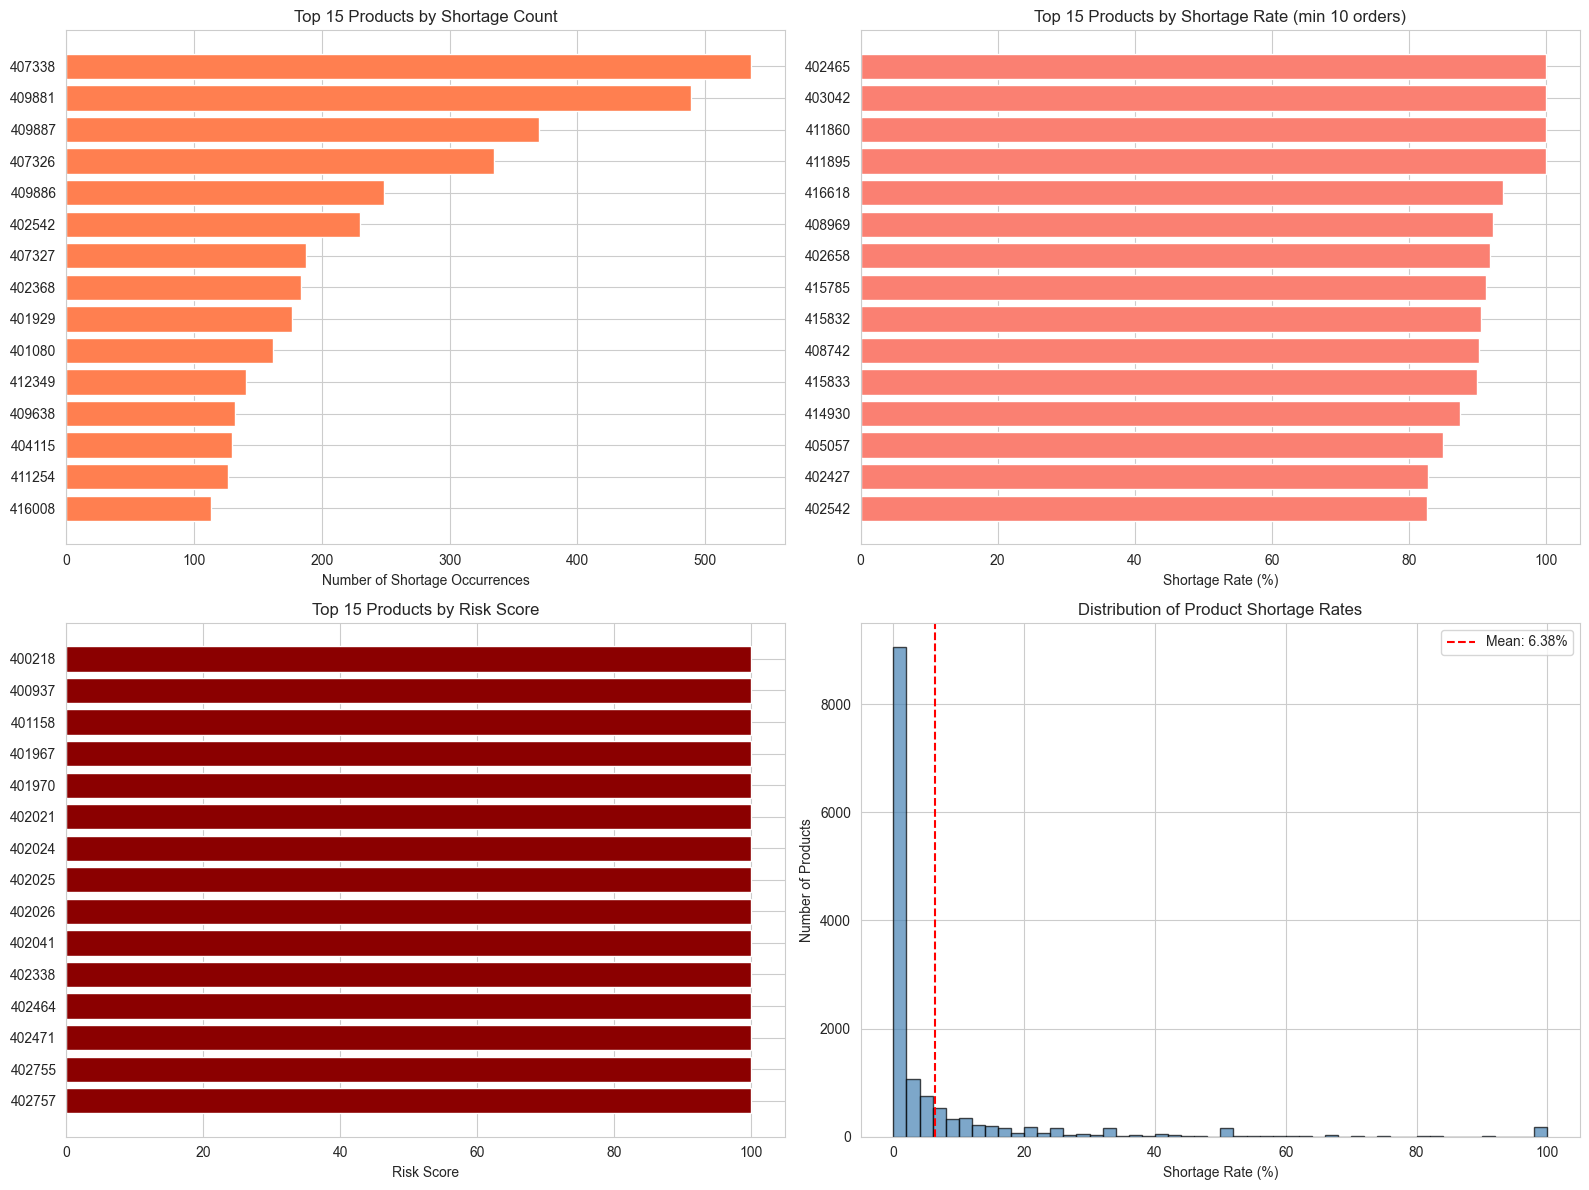

In [7]:
# Visualize top products with shortages
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top products by shortage count
top_shortage_products = product_stats.nlargest(15, 'shortage_count')
axes[0, 0].barh(range(len(top_shortage_products)), top_shortage_products['shortage_count'], 
                color='coral')
axes[0, 0].set_yticks(range(len(top_shortage_products)))
axes[0, 0].set_yticklabels(top_shortage_products['product_code'])
axes[0, 0].set_xlabel('Number of Shortage Occurrences')
axes[0, 0].set_title('Top 15 Products by Shortage Count')
axes[0, 0].invert_yaxis()

# 2. Top products by shortage rate
top_rate_products = product_stats[product_stats['total_orders'] >= 10].nlargest(15, 'shortage_rate')
axes[0, 1].barh(range(len(top_rate_products)), top_rate_products['shortage_rate'], 
                color='salmon')
axes[0, 1].set_yticks(range(len(top_rate_products)))
axes[0, 1].set_yticklabels(top_rate_products['product_code'])
axes[0, 1].set_xlabel('Shortage Rate (%)')
axes[0, 1].set_title('Top 15 Products by Shortage Rate (min 10 orders)')
axes[0, 1].invert_yaxis()

# 3. Top products by risk score
top_risk_products = product_stats.nlargest(15, 'risk_score')
axes[1, 0].barh(range(len(top_risk_products)), top_risk_products['risk_score'], 
                color='darkred')
axes[1, 0].set_yticks(range(len(top_risk_products)))
axes[1, 0].set_yticklabels(top_risk_products['product_code'])
axes[1, 0].set_xlabel('Risk Score')
axes[1, 0].set_title('Top 15 Products by Risk Score')
axes[1, 0].invert_yaxis()

# 4. Shortage rate distribution
axes[1, 1].hist(product_stats['shortage_rate'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Shortage Rate (%)')
axes[1, 1].set_ylabel('Number of Products')
axes[1, 1].set_title('Distribution of Product Shortage Rates')
axes[1, 1].axvline(product_stats['shortage_rate'].mean(), color='red', 
                   linestyle='--', label=f"Mean: {product_stats['shortage_rate'].mean():.2f}%")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


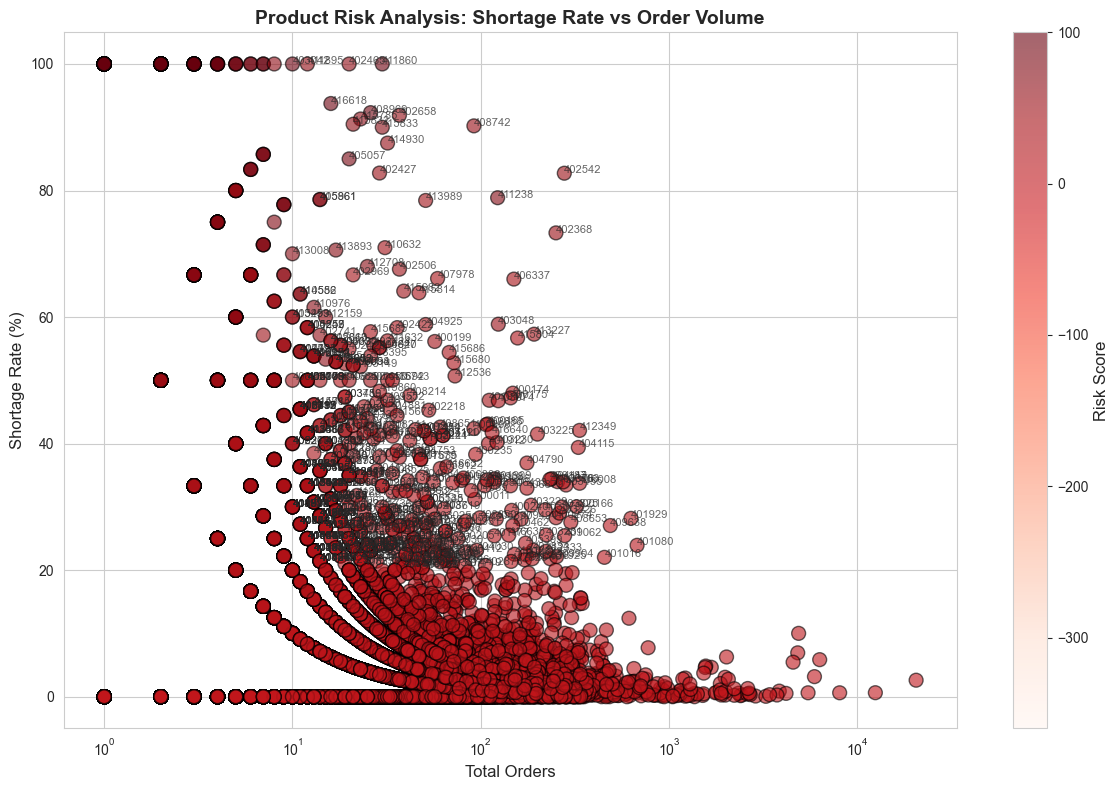


High-risk products (shortage rate > 20%, min 10 orders): 472


In [8]:
# Scatter plot: Shortage rate vs Total orders
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(product_stats['total_orders'], product_stats['shortage_rate'], 
                    c=product_stats['risk_score'], cmap='Reds', s=100, alpha=0.6, edgecolors='black')

ax.set_xlabel('Total Orders', fontsize=12)
ax.set_ylabel('Shortage Rate (%)', fontsize=12)
ax.set_title('Product Risk Analysis: Shortage Rate vs Order Volume', fontsize=14, fontweight='bold')
ax.set_xscale('log')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Risk Score', fontsize=12)

# Highlight high-risk products
high_risk = product_stats[(product_stats['shortage_rate'] > 20) & (product_stats['total_orders'] >= 10)]
if len(high_risk) > 0:
    for _, row in high_risk.iterrows():
        ax.annotate(str(int(row['product_code'])), 
                   (row['total_orders'], row['shortage_rate']),
                   fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

print(f"\nHigh-risk products (shortage rate > 20%, min 10 orders): {len(high_risk)}")


## 4. Customer Impact Analysis


In [9]:
# Customer-level shortage analysis
customer_stats = aggregated.groupby('customer_number').agg({
    'order_number': 'count',  # Total orders
    'has_shortage': 'sum',  # Count of shortages
    'shortage_qty': 'sum',  # Total shortage quantity
    'ordered_qty': 'sum',  # Total ordered
    'received_qty': 'sum',  # Total received
    'product_code': 'nunique',  # Unique products ordered
    'shortage_pct': 'mean'  # Average shortage percentage
}).reset_index()

customer_stats.columns = ['customer_number', 'total_orders', 'shortage_count', 'total_shortage_qty', 
                         'total_ordered_qty', 'total_received_qty', 'unique_products', 'avg_shortage_pct']

# Calculate metrics
customer_stats['shortage_rate'] = (customer_stats['shortage_count'] / customer_stats['total_orders'] * 100)
customer_stats['fulfillment_rate'] = (customer_stats['total_received_qty'] / customer_stats['total_ordered_qty'] * 100)
customer_stats['impact_score'] = (
    (customer_stats['shortage_rate'] / 100) * 0.5 +  # 50% weight on frequency
    (1 - customer_stats['fulfillment_rate'] / 100) * 0.3 +  # 30% weight on severity
    (customer_stats['total_orders'] / customer_stats['total_orders'].max()) * 0.2  # 20% weight on volume
) * 100

print("Top 20 Customers by Impact Score (Most Affected):")
print(customer_stats.nlargest(20, 'impact_score')[['customer_number', 'total_orders', 'shortage_count', 
                                                    'shortage_rate', 'fulfillment_rate', 'impact_score']])


Top 20 Customers by Impact Score (Most Affected):
     customer_number  total_orders  shortage_count  shortage_rate  \
167            30183             3               3         100.00   
329            30361             1               1         100.00   
539            30589             1               1         100.00   
588           400377             1               1         100.00   
538            30588             4               3          75.00   
319            30350            12               8          66.67   
332            30364             1               1         100.00   
533            30583             1               1         100.00   
315            30346             2               2         100.00   
515            30565             5               3          60.00   
603           400447            29              14          48.28   
409            30450             4               2          50.00   
74             30082            17               9   

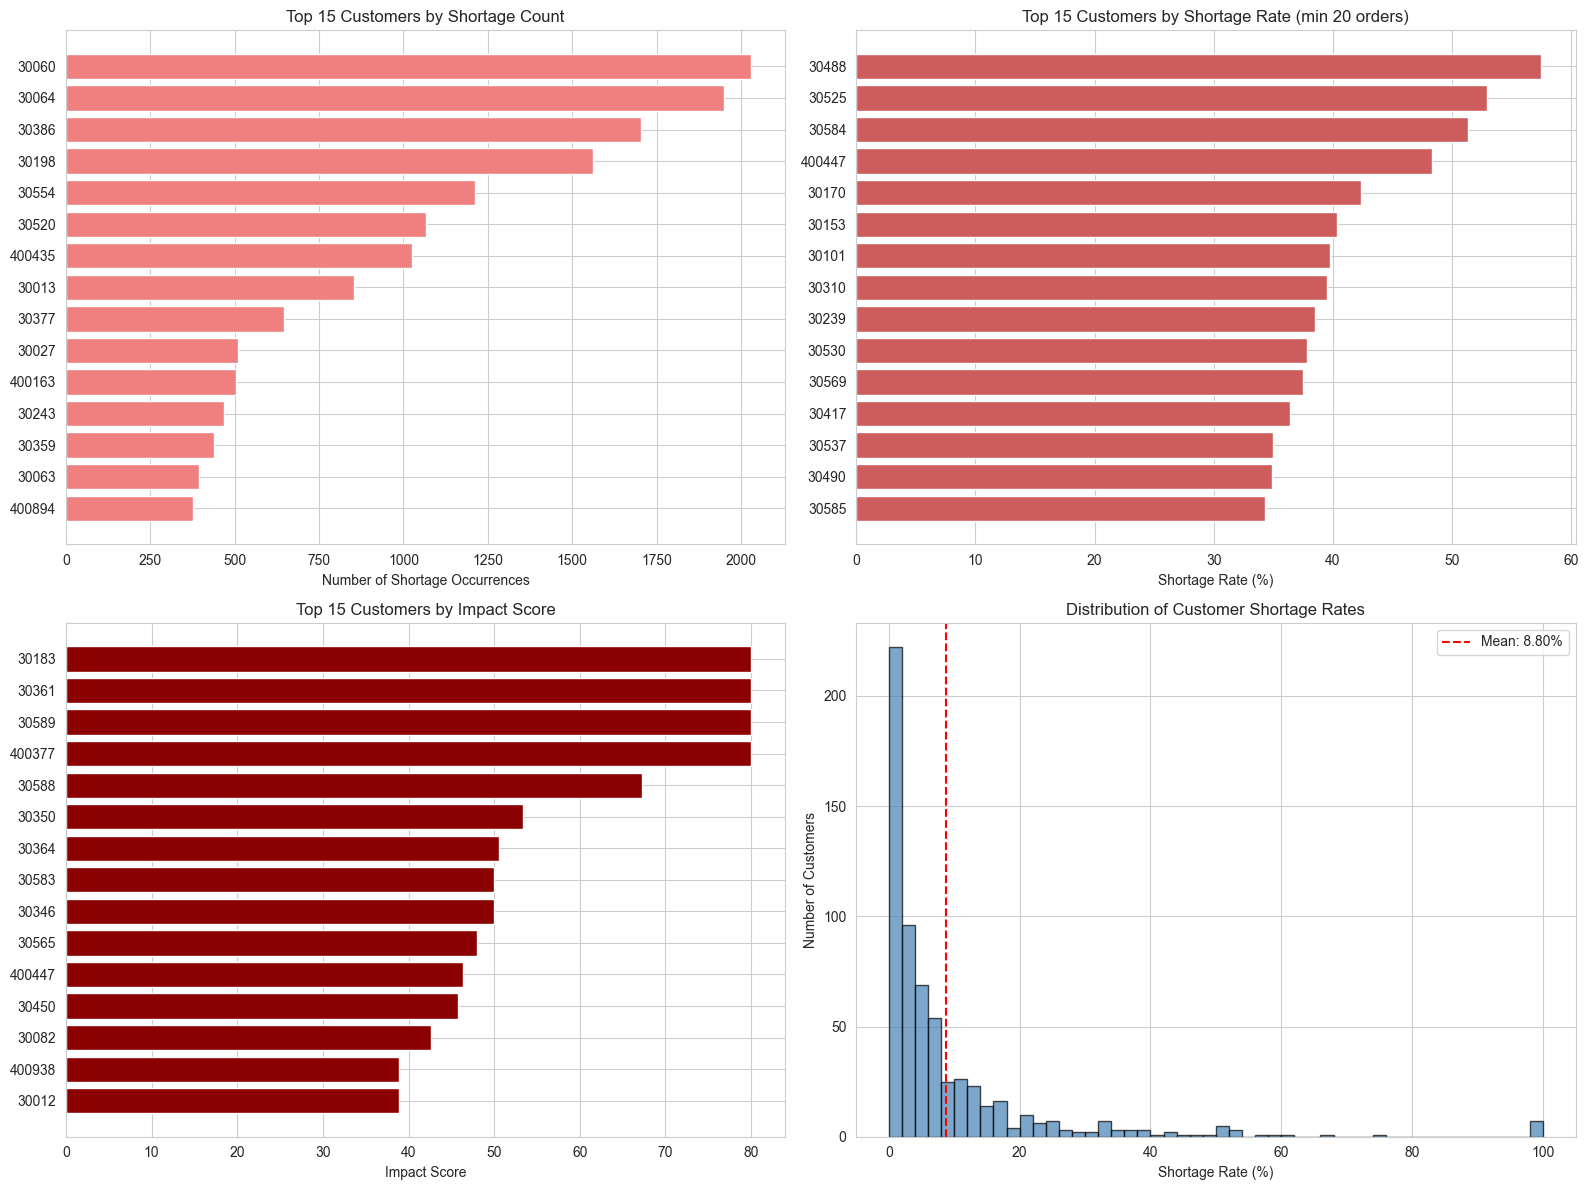

In [10]:
# Visualize customer impact
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top customers by shortage count
top_shortage_customers = customer_stats.nlargest(15, 'shortage_count')
axes[0, 0].barh(range(len(top_shortage_customers)), top_shortage_customers['shortage_count'], 
                color='lightcoral')
axes[0, 0].set_yticks(range(len(top_shortage_customers)))
axes[0, 0].set_yticklabels(top_shortage_customers['customer_number'])
axes[0, 0].set_xlabel('Number of Shortage Occurrences')
axes[0, 0].set_title('Top 15 Customers by Shortage Count')
axes[0, 0].invert_yaxis()

# 2. Top customers by shortage rate
top_rate_customers = customer_stats[customer_stats['total_orders'] >= 20].nlargest(15, 'shortage_rate')
if len(top_rate_customers) > 0:
    axes[0, 1].barh(range(len(top_rate_customers)), top_rate_customers['shortage_rate'], 
                    color='indianred')
    axes[0, 1].set_yticks(range(len(top_rate_customers)))
    axes[0, 1].set_yticklabels(top_rate_customers['customer_number'])
    axes[0, 1].set_xlabel('Shortage Rate (%)')
    axes[0, 1].set_title('Top 15 Customers by Shortage Rate (min 20 orders)')
    axes[0, 1].invert_yaxis()
else:
    axes[0, 1].text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('Top Customers by Shortage Rate')

# 3. Top customers by impact score
top_impact_customers = customer_stats.nlargest(15, 'impact_score')
axes[1, 0].barh(range(len(top_impact_customers)), top_impact_customers['impact_score'], 
                color='darkred')
axes[1, 0].set_yticks(range(len(top_impact_customers)))
axes[1, 0].set_yticklabels(top_impact_customers['customer_number'])
axes[1, 0].set_xlabel('Impact Score')
axes[1, 0].set_title('Top 15 Customers by Impact Score')
axes[1, 0].invert_yaxis()

# 4. Customer shortage rate distribution
axes[1, 1].hist(customer_stats['shortage_rate'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Shortage Rate (%)')
axes[1, 1].set_ylabel('Number of Customers')
axes[1, 1].set_title('Distribution of Customer Shortage Rates')
axes[1, 1].axvline(customer_stats['shortage_rate'].mean(), color='red', 
                   linestyle='--', label=f"Mean: {customer_stats['shortage_rate'].mean():.2f}%")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [11]:
# Customer-Product combination analysis (identify high-risk customer-product pairs)
customer_product_stats = aggregated.groupby(['customer_number', 'product_code']).agg({
    'order_number': 'count',
    'has_shortage': 'sum',
    'shortage_qty': 'sum',
    'shortage_pct': 'mean'
}).reset_index()

customer_product_stats.columns = ['customer_number', 'product_code', 'order_count', 
                                  'shortage_count', 'total_shortage_qty', 'avg_shortage_pct']

customer_product_stats['shortage_rate'] = (customer_product_stats['shortage_count'] / 
                                           customer_product_stats['order_count'] * 100)

# High-risk combinations: frequent orders with high shortage rate
high_risk_combinations = customer_product_stats[
    (customer_product_stats['order_count'] >= 5) & 
    (customer_product_stats['shortage_rate'] > 30)
].sort_values('shortage_rate', ascending=False)

print(f"High-risk customer-product combinations (>=5 orders, >30% shortage rate): {len(high_risk_combinations)}")
print("\nTop 20 High-Risk Customer-Product Combinations:")
print(high_risk_combinations.head(20)[['customer_number', 'product_code', 'order_count', 
                                       'shortage_count', 'shortage_rate']])


High-risk customer-product combinations (>=5 orders, >30% shortage rate): 465

Top 20 High-Risk Customer-Product Combinations:
       customer_number  product_code  order_count  shortage_count  \
14765           400894        401158            7               7   
6387             30285        411895           12              12   
10310            30499        407524            6               6   
411              30013        412954            5               5   
13910           400282        408294            7               7   
6900             30317        411860           30              30   
6786             30310        403280            5               5   
6393             30285        414168            5               5   
6593             30295        413563            5               5   
11739            30544        414289            8               8   
3915             30170        415833           10              10   
4254             30198        402465         

## 5. Temporal Pattern Analysis


In [12]:
# Monthly shortage patterns
monthly_stats = aggregated.groupby('po_created_month').agg({
    'order_number': 'count',
    'has_shortage': 'sum',
    'shortage_qty': 'sum'
}).reset_index()

monthly_stats['shortage_rate'] = (monthly_stats['has_shortage'] / monthly_stats['order_number'] * 100)
monthly_stats['month_name'] = pd.to_datetime(monthly_stats['po_created_month'], format='%m').dt.strftime('%B')

# Weekly patterns
weekly_stats = aggregated.groupby('po_created_week').agg({
    'order_number': 'count',
    'has_shortage': 'sum',
    'shortage_qty': 'sum'
}).reset_index()

weekly_stats['shortage_rate'] = (weekly_stats['has_shortage'] / weekly_stats['order_number'] * 100)

# Day of week patterns
day_stats = aggregated.groupby(['po_created_dayofweek', 'po_created_dayname']).agg({
    'order_number': 'count',
    'has_shortage': 'sum',
    'shortage_qty': 'sum'
}).reset_index()

day_stats['shortage_rate'] = (day_stats['has_shortage'] / day_stats['order_number'] * 100)
day_stats = day_stats.sort_values('po_created_dayofweek')

print("Monthly Shortage Patterns:")
print(monthly_stats)
print("\nDay of Week Shortage Patterns:")
print(day_stats[['po_created_dayname', 'order_number', 'has_shortage', 'shortage_rate']])


Monthly Shortage Patterns:
    po_created_month  order_number  has_shortage  shortage_qty  shortage_rate  \
0                  1         59664          1866      31046.09           3.13   
1                  2         55506          1674      39635.88           3.02   
2                  3         58898          1971      36124.67           3.35   
3                  4         59880          2481      40765.95           4.14   
4                  5         60687          2258      47001.41           3.72   
5                  6         56142          2132      62940.11           3.80   
6                  7         57092          1809      41885.00           3.17   
7                  8         61442          2169      66020.32           3.53   
8                  9        131070          6246     100854.95           4.77   
9                 10         67766          2623      32231.61           3.87   
10                11         63194          1888      28101.27           2.99   
1

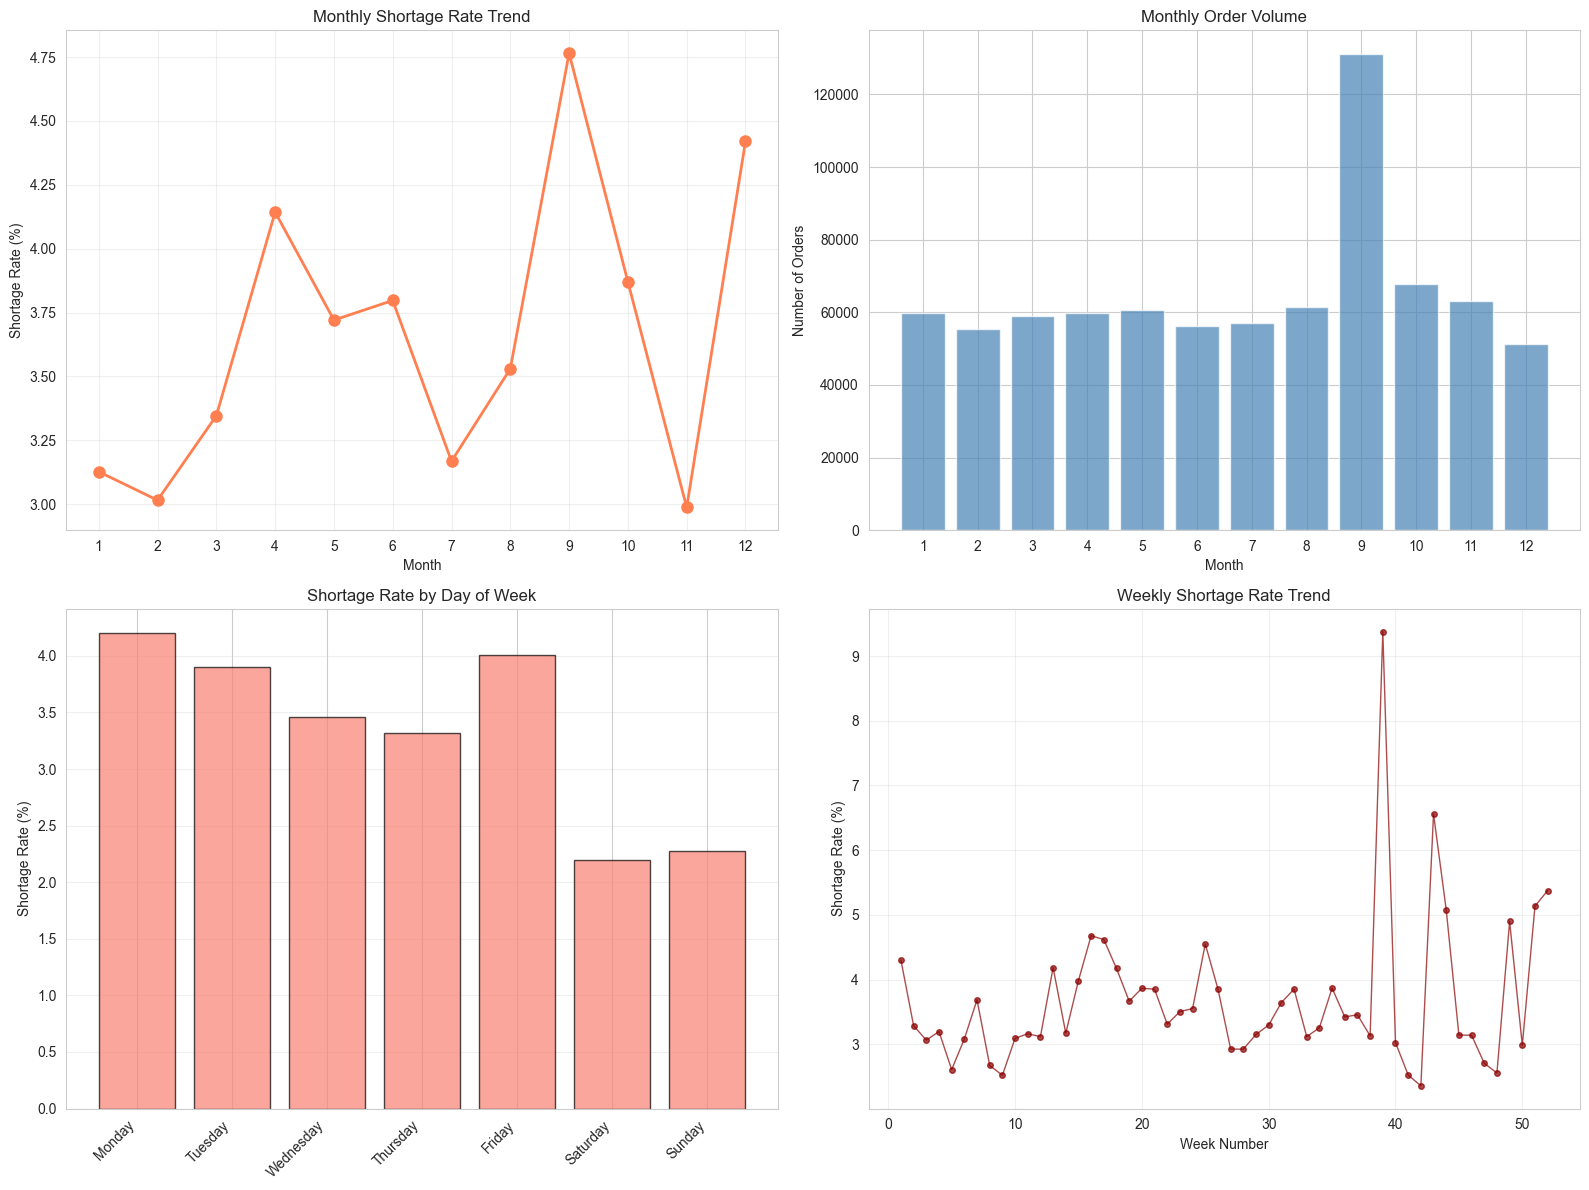

In [13]:
# Visualize temporal patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Monthly shortage rate
axes[0, 0].plot(monthly_stats['po_created_month'], monthly_stats['shortage_rate'], 
                marker='o', linewidth=2, markersize=8, color='coral')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Shortage Rate (%)')
axes[0, 0].set_title('Monthly Shortage Rate Trend')
axes[0, 0].set_xticks(monthly_stats['po_created_month'])
axes[0, 0].grid(True, alpha=0.3)

# 2. Monthly order volume
axes[0, 1].bar(monthly_stats['po_created_month'], monthly_stats['order_number'], 
               color='steelblue', alpha=0.7)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Orders')
axes[0, 1].set_title('Monthly Order Volume')
axes[0, 1].set_xticks(monthly_stats['po_created_month'])

# 3. Day of week shortage rate
axes[1, 0].bar(range(len(day_stats)), day_stats['shortage_rate'], 
               color='salmon', alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(len(day_stats)))
axes[1, 0].set_xticklabels(day_stats['po_created_dayname'], rotation=45, ha='right')
axes[1, 0].set_ylabel('Shortage Rate (%)')
axes[1, 0].set_title('Shortage Rate by Day of Week')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Weekly shortage rate trend
axes[1, 1].plot(weekly_stats['po_created_week'], weekly_stats['shortage_rate'], 
                marker='o', linewidth=1, markersize=4, color='darkred', alpha=0.7)
axes[1, 1].set_xlabel('Week Number')
axes[1, 1].set_ylabel('Shortage Rate (%)')
axes[1, 1].set_title('Weekly Shortage Rate Trend')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Plant and Storage Location Analysis



In [14]:
# Plant-level analysis
plant_stats = aggregated.groupby('plant').agg({
    'order_number': 'count',
    'has_shortage': 'sum',
    'shortage_qty': 'sum',
    'product_code': 'nunique',
    'customer_number': 'nunique'
}).reset_index()

plant_stats.columns = ['plant', 'total_orders', 'shortage_count', 'total_shortage_qty', 
                       'unique_products', 'unique_customers']
plant_stats['shortage_rate'] = (plant_stats['shortage_count'] / plant_stats['total_orders'] * 100)

# Storage location analysis
storage_stats = aggregated.groupby(['plant', 'storage_location']).agg({
    'order_number': 'count',
    'has_shortage': 'sum',
    'shortage_qty': 'sum'
}).reset_index()

storage_stats.columns = ['plant', 'storage_location', 'total_orders', 'shortage_count', 'total_shortage_qty']
storage_stats['shortage_rate'] = (storage_stats['shortage_count'] / storage_stats['total_orders'] * 100)

print("Plant-Level Statistics:")
print(plant_stats.sort_values('shortage_rate', ascending=False))
print("\n\nTop Storage Locations by Shortage Rate:")
print(storage_stats.nlargest(20, 'shortage_rate')[['plant', 'storage_location', 'total_orders', 
                                                    'shortage_count', 'shortage_rate']])


Plant-Level Statistics:
   plant  total_orders  shortage_count  total_shortage_qty  unique_products  \
0   1000          3636             148              986.00              118   
2  30588        578926           22674           495133.25            13699   
1   1001        200072            6562            60201.87             6970   

   unique_customers  shortage_rate  
0                22           4.07  
2               597           3.92  
1               242           3.28  


Top Storage Locations by Shortage Rate:
    plant  storage_location  total_orders  shortage_count  shortage_rate
4    1001           2003.00           180              82          45.56
12  30588           2003.00          3568             681          19.09
15  30588           2006.00           166              27          16.27
0    1000           2008.00           595              40           6.72
17  30588           2012.00        182686           10734           5.88
16  30588           2007.00    

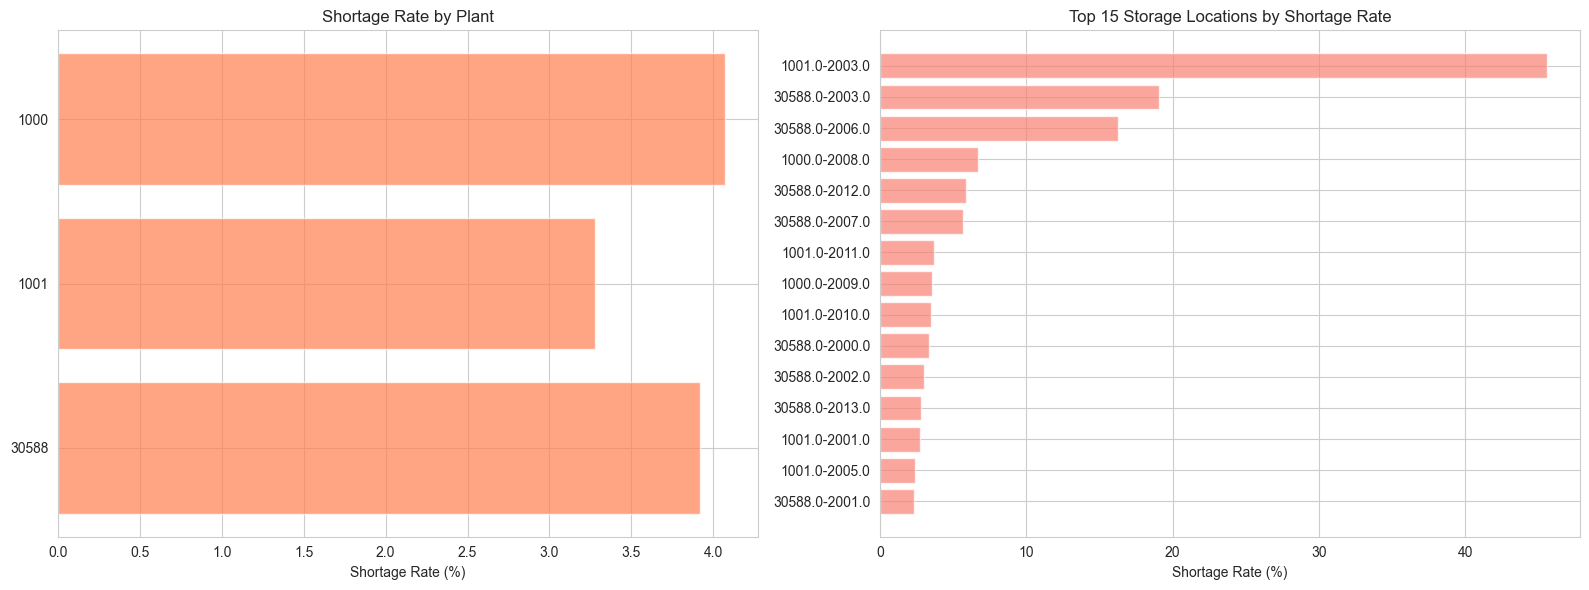

In [15]:
# Visualize plant and storage location patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plant shortage rates
axes[0].barh(range(len(plant_stats)), plant_stats['shortage_rate'], color='coral', alpha=0.7)
axes[0].set_yticks(range(len(plant_stats)))
axes[0].set_yticklabels(plant_stats['plant'])
axes[0].set_xlabel('Shortage Rate (%)')
axes[0].set_title('Shortage Rate by Plant')
axes[0].invert_yaxis()

# Storage location shortage rates (top 15)
top_storage = storage_stats.nlargest(15, 'shortage_rate')
axes[1].barh(range(len(top_storage)), top_storage['shortage_rate'], color='salmon', alpha=0.7)
axes[1].set_yticks(range(len(top_storage)))
axes[1].set_yticklabels([f"{row['plant']}-{row['storage_location']}" for _, row in top_storage.iterrows()])
axes[1].set_xlabel('Shortage Rate (%)')
axes[1].set_title('Top 15 Storage Locations by Shortage Rate')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 7. Risk Scoring and Prioritization


In [16]:
# Create a comprehensive risk scoring system
# Combine product risk with customer impact

# Get high-risk products
high_risk_products = product_stats[product_stats['risk_score'] > 50].copy()
high_risk_products = high_risk_products.sort_values('risk_score', ascending=False)

# Get high-impact customers
high_impact_customers = customer_stats[customer_stats['impact_score'] > 30].copy()
high_impact_customers = high_impact_customers.sort_values('impact_score', ascending=False)

print("=== PRIORITY PRODUCTS FOR AI AGENT MONITORING ===")
print(f"Products with risk score > 50: {len(high_risk_products)}")
print("\nTop 30 High-Risk Products:")
print(high_risk_products[['product_code', 'total_orders', 'shortage_count', 
                          'shortage_rate', 'fulfillment_rate', 'risk_score']].head(30))

print("\n\n=== PRIORITY CUSTOMERS FOR AI AGENT CONTACT ===")
print(f"Customers with impact score > 30: {len(high_impact_customers)}")
print("\nTop 30 High-Impact Customers:")
print(high_impact_customers[['customer_number', 'total_orders', 'shortage_count', 
                            'shortage_rate', 'fulfillment_rate', 'impact_score']].head(30))


=== PRIORITY PRODUCTS FOR AI AGENT MONITORING ===
Products with risk score > 50: 332

Top 30 High-Risk Products:
       product_code  total_orders  shortage_count  shortage_rate  \
190          400218             1               1         100.00   
10323        412724             1               1         100.00   
7954         409920             1               1         100.00   
7967         409940             1               1         100.00   
7971         409945             1               1         100.00   
8053         410057             3               3         100.00   
8234         410299             1               1         100.00   
8343         410421             2               2         100.00   
8418         410512             1               1         100.00   
8434         410530             1               1         100.00   
8513         410622             1               1         100.00   
8682         410809             2               2         100.00   
868

In [17]:
# Create customer-product risk matrix
# This identifies which customer-product combinations should trigger AI agent alerts

# Merge customer and product stats
customer_product_risk = customer_product_stats.merge(
    product_stats[['product_code', 'risk_score']], on='product_code', how='left'
).merge(
    customer_stats[['customer_number', 'impact_score']], on='customer_number', how='left'
)

# Calculate combined risk score
customer_product_risk['combined_risk_score'] = (
    customer_product_risk['risk_score'].fillna(0) * 0.4 +  # Product risk (40%)
    customer_product_risk['impact_score'].fillna(0) * 0.3 +  # Customer impact (30%)
    (customer_product_risk['shortage_rate'] / 100) * 100 * 0.3  # Historical combo rate (30%)
)

# Filter for actionable combinations (min 3 orders)
actionable_combinations = customer_product_risk[
    customer_product_risk['order_count'] >= 3
].sort_values('combined_risk_score', ascending=False)

print(f"=== AI AGENT ALERT TRIGGERS ===")
print(f"Customer-product combinations requiring immediate attention: {len(actionable_combinations[actionable_combinations['combined_risk_score'] > 40])}")
print("\nTop 30 High-Risk Customer-Product Combinations for AI Agent Alerts:")
print(actionable_combinations.head(30)[['customer_number', 'product_code', 'order_count', 
                                        'shortage_count', 'shortage_rate', 'combined_risk_score']])


=== AI AGENT ALERT TRIGGERS ===
Customer-product combinations requiring immediate attention: 185

Top 30 High-Risk Customer-Product Combinations for AI Agent Alerts:
       customer_number  product_code  order_count  shortage_count  \
9983             30490        402755            4               4   
8644             30434        405355            3               3   
10310            30499        407524            6               6   
6635             30296        414845            3               3   
6                30000        407862            3               3   
802              30027        408717            3               3   
6393             30285        414168            5               5   
7225             30362        407119            3               3   
10576            30512        411750            3               3   
1839             30064        413888            3               3   
2636             30095        415029            3               3   
1439  

## 8. Product Data Analysis (Categories, Vendors, Temperature Conditions)


In [ ]:
# Analyze product data attributes
# Even without direct matching, we can analyze product characteristics

print("=== PRODUCT DATA ANALYSIS ===")

# Category analysis
category_counts = product_df['category'].value_counts().head(20)
print(f"\nTop 20 Product Categories:")
print(category_counts)

# Vendor analysis
vendor_counts = product_df['vendorName'].value_counts().head(20)
print(f"\n\nTop 20 Vendors:")
print(vendor_counts)

# Temperature condition analysis
temp_analysis = product_df.groupby('temperatureCondition').agg({
    'salesUnitGtin': 'count',
    'category': 'nunique',
    'vendorName': 'nunique'
}).reset_index()
temp_analysis.columns = ['temperature', 'product_count', 'unique_categories', 'unique_vendors']
print(f"\n\nTemperature Condition Analysis:")
print(temp_analysis.sort_values('product_count', ascending=False))

# Country of origin analysis
country_analysis = product_df.groupby('countryOfOrigin').agg({
    'salesUnitGtin': 'count',
    'category': 'nunique',
    'vendorName': 'nunique'
}).reset_index()
country_analysis.columns = ['country', 'product_count', 'unique_categories', 'unique_vendors']
print(f"\n\nTop 10 Countries of Origin:")
print(country_analysis.nlargest(10, 'product_count'))


In [ ]:
# Visualize product data attributes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top categories
top_categories = product_df['category'].value_counts().head(15)
axes[0, 0].barh(range(len(top_categories)), top_categories.values, color='steelblue', alpha=0.7)
axes[0, 0].set_yticks(range(len(top_categories)))
axes[0, 0].set_yticklabels(top_categories.index)
axes[0, 0].set_xlabel('Number of Products')
axes[0, 0].set_title('Top 15 Product Categories')
axes[0, 0].invert_yaxis()

# 2. Top vendors
top_vendors = product_df['vendorName'].value_counts().head(15)
axes[0, 1].barh(range(len(top_vendors)), top_vendors.values, color='coral', alpha=0.7)
axes[0, 1].set_yticks(range(len(top_vendors)))
axes[0, 1].set_yticklabels([v[:30] + '...' if len(v) > 30 else v for v in top_vendors.index])
axes[0, 1].set_xlabel('Number of Products')
axes[0, 1].set_title('Top 15 Vendors')
axes[0, 1].invert_yaxis()

# 3. Temperature distribution
temp_counts = product_df['temperatureCondition'].value_counts().sort_index()
axes[1, 0].bar(range(len(temp_counts)), temp_counts.values, color='salmon', alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(len(temp_counts)))
axes[1, 0].set_xticklabels([f'{temp}°C' if pd.notna(temp) else 'Unknown' for temp in temp_counts.index])
axes[1, 0].set_ylabel('Number of Products')
axes[1, 0].set_title('Product Distribution by Temperature Condition')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Top countries of origin
top_countries = product_df['countryOfOrigin'].value_counts().head(15)
axes[1, 1].barh(range(len(top_countries)), top_countries.values, color='lightgreen', alpha=0.7)
axes[1, 1].set_yticks(range(len(top_countries)))
axes[1, 1].set_yticklabels(top_countries.index.upper())
axes[1, 1].set_xlabel('Number of Products')
axes[1, 1].set_title('Top 15 Countries of Origin')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nTotal products analyzed: {len(product_df)}")
print(f"Products with temperature condition: {product_df['temperatureCondition'].notna().sum()}")
print(f"Products with vendor info: {product_df['vendorName'].notna().sum()}")
print(f"Products with country of origin: {product_df['countryOfOrigin'].notna().sum()}")


### Note on Product Data Integration

The product data contains rich information (categories, vendors, temperature conditions, substitutions) that could enhance the risk analysis and substitution logic. If you have a mapping between `product_code` (in purchase data) and `salesUnitGtin` (in product data), you can join these datasets to:

1. **Enhanced Risk Scoring**: Use product categories, temperature requirements, and vendor reliability
2. **Substitution Logic**: Leverage the `substitutions` field in product data for "good-better-best" replacement suggestions
3. **Vendor Analysis**: Identify vendor-specific shortage patterns
4. **Category-based Patterns**: Analyze shortages by product category

Example join code (if mapping exists):
```python
# If you have a mapping file or can extract product_code from GTIN
# enriched_data = aggregated.merge(product_df, left_on='product_code', right_on='some_mapping_key', how='left')
```


## 9. Risk Scoring and Prioritization


In [18]:
# Create a summary heatmap: Customer vs Product risk
# This shows which customers should be prioritized when ordering high-risk products

# Select top customers and products for visualization
if len(high_impact_customers) > 0 and len(high_risk_products) > 0:
    top_customers = high_impact_customers.head(20)['customer_number'].tolist()
    top_products = high_risk_products.head(20)['product_code'].tolist()
    
    # Create risk matrix
    risk_matrix = customer_product_risk[
        (customer_product_risk['customer_number'].isin(top_customers)) &
        (customer_product_risk['product_code'].isin(top_products))
    ].pivot(index='customer_number', columns='product_code', values='combined_risk_score')
    
    if len(risk_matrix) > 0:
        fig, ax = plt.subplots(figsize=(16, 10))
        sns.heatmap(risk_matrix, annot=False, fmt='.1f', cmap='Reds', 
                    cbar_kws={'label': 'Combined Risk Score'}, ax=ax)
        ax.set_title('Customer-Product Risk Matrix\n(Red = High Risk, Requires AI Agent Alert)', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Product Code', fontsize=12)
        ax.set_ylabel('Customer Number', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print("Insufficient overlapping data for risk matrix visualization")
else:
    print("Insufficient data for risk matrix visualization")


Insufficient overlapping data for risk matrix visualization


## 8. Key Insights and Recommendations


In [19]:
print("="*80)
print("KEY INSIGHTS AND RECOMMENDATIONS FOR VALIO AIMO AI AGENT SYSTEM")
print("="*80)

print("\n1. PRODUCT RISK PRIORITIZATION:")
print(f"   - {len(high_risk_products)} products have high risk scores (>50)")
if len(high_risk_products) > 0:
    print(f"   - Top risk product: {int(high_risk_products.iloc[0]['product_code'])}")
    print(f"     (Risk Score: {high_risk_products.iloc[0]['risk_score']:.2f}, ")
    print(f"      Shortage Rate: {high_risk_products.iloc[0]['shortage_rate']:.2f}%)")
print("   - RECOMMENDATION: When these products are ordered, trigger immediate AI agent monitoring")

print("\n2. CUSTOMER IMPACT PRIORITIZATION:")
print(f"   - {len(high_impact_customers)} customers are highly impacted by shortages")
if len(high_impact_customers) > 0:
    print(f"   - Top impacted customer: {int(high_impact_customers.iloc[0]['customer_number'])}")
    print(f"     (Impact Score: {high_impact_customers.iloc[0]['impact_score']:.2f}, ")
    print(f"      Shortage Rate: {high_impact_customers.iloc[0]['shortage_rate']:.2f}%)")
print("   - RECOMMENDATION: Proactively contact these customers for high-risk product orders")

print("\n3. TEMPORAL PATTERNS:")
if len(monthly_stats) > 1:
    worst_month_idx = monthly_stats['shortage_rate'].idxmax()
    worst_month = monthly_stats.loc[worst_month_idx]
    print(f"   - Worst month: Month {int(worst_month['po_created_month'])}")
    print(f"     (Shortage Rate: {worst_month['shortage_rate']:.2f}%)")
if len(day_stats) > 0:
    worst_day_idx = day_stats['shortage_rate'].idxmax()
    worst_day = day_stats.loc[worst_day_idx]
    print(f"   - Worst day of week: {worst_day['po_created_dayname']}")
    print(f"     (Shortage Rate: {worst_day['shortage_rate']:.2f}%)")
print("   - RECOMMENDATION: Increase AI agent capacity during high-risk periods")

print("\n4. PLANT/STORAGE LOCATION INSIGHTS:")
if len(plant_stats) > 0:
    worst_plant_idx = plant_stats['shortage_rate'].idxmax()
    worst_plant = plant_stats.loc[worst_plant_idx]
    print(f"   - Plant with highest shortage rate: {int(worst_plant['plant'])}")
    print(f"     (Shortage Rate: {worst_plant['shortage_rate']:.2f}%)")
print("   - RECOMMENDATION: Review inventory management at high-risk locations")

print("\n5. AI AGENT ALERT TRIGGERS:")
high_priority_combos = actionable_combinations[actionable_combinations['combined_risk_score'] > 40]
print(f"   - {len(high_priority_combos)} customer-product combinations require immediate alerts")
print("   - RECOMMENDATION: When these combinations occur, immediately trigger AI agent:")
print("     a. Pre-picking: Check stock availability")
print("     b. During picking: If shortage detected, contact customer proactively")
print("     c. Post-delivery: Follow up for any remaining issues")

print("\n6. MITIGATION SCALE RECOMMENDATION:")
print("   - Implement a 3-tier mitigation scale:")
print("     Tier 1 (Risk Score > 60): Immediate AI agent call + replacement proposal")
print("     Tier 2 (Risk Score 40-60): AI agent call during picking if shortage detected")
print("     Tier 3 (Risk Score 20-40): SMS/Text notification with replacement options")
print("     Tier 4 (Risk Score < 20): Standard process")

print("\n" + "="*80)


KEY INSIGHTS AND RECOMMENDATIONS FOR VALIO AIMO AI AGENT SYSTEM

1. PRODUCT RISK PRIORITIZATION:
   - 332 products have high risk scores (>50)
   - Top risk product: 400218
     (Risk Score: 100.00, 
      Shortage Rate: 100.00%)
   - RECOMMENDATION: When these products are ordered, trigger immediate AI agent monitoring

2. CUSTOMER IMPACT PRIORITIZATION:
   - 25 customers are highly impacted by shortages
   - Top impacted customer: 30183
     (Impact Score: 80.00, 
      Shortage Rate: 100.00%)
   - RECOMMENDATION: Proactively contact these customers for high-risk product orders

3. TEMPORAL PATTERNS:
   - Worst month: Month 9
     (Shortage Rate: 4.77%)
   - Worst day of week: Monday
     (Shortage Rate: 4.21%)
   - RECOMMENDATION: Increase AI agent capacity during high-risk periods

4. PLANT/STORAGE LOCATION INSIGHTS:
   - Plant with highest shortage rate: 1000
     (Shortage Rate: 4.07%)
   - RECOMMENDATION: Review inventory management at high-risk locations

5. AI AGENT ALERT TRIG

## 9. Export Risk Scores for Integration


In [20]:
# Export key risk scores for integration with AI agent system

# Product risk scores
product_risk_export = product_stats[['product_code', 'total_orders', 'shortage_rate', 
                                     'fulfillment_rate', 'risk_score']].copy()
product_risk_export = product_risk_export.sort_values('risk_score', ascending=False)

# Customer impact scores
customer_impact_export = customer_stats[['customer_number', 'total_orders', 'shortage_rate', 
                                         'fulfillment_rate', 'impact_score']].copy()
customer_impact_export = customer_impact_export.sort_values('impact_score', ascending=False)

# High-priority combinations
priority_combos_export = actionable_combinations[
    actionable_combinations['combined_risk_score'] > 40
][['customer_number', 'product_code', 'order_count', 'shortage_rate', 
   'combined_risk_score']].copy()

print("Exporting risk scores...")
product_risk_export.to_csv('product_risk_scores.csv', index=False)
customer_impact_export.to_csv('customer_impact_scores.csv', index=False)
priority_combos_export.to_csv('ai_agent_priority_combinations.csv', index=False)

print(f"✓ Exported {len(product_risk_export)} product risk scores")
print(f"✓ Exported {len(customer_impact_export)} customer impact scores")
print(f"✓ Exported {len(priority_combos_export)} priority combinations for AI agent alerts")

print("\nThese CSV files can be integrated into the AI agent system for real-time risk assessment.")


Exporting risk scores...
✓ Exported 14110 product risk scores
✓ Exported 621 customer impact scores
✓ Exported 185 priority combinations for AI agent alerts

These CSV files can be integrated into the AI agent system for real-time risk assessment.
